# LAPORAN CLUSTERING DAN SEGMENTASI DATA CITRA SENTINEL-2

## Pendahuluan
Pada kegiatan ini dilakukan pengolahan data citra Sentinel-2 untuk menganalisis 100 sampel wilayah yang terdiri dari 50 sampel sawah dan 50 sampel non sawah. Data yang digunakan adalah band B02, B03, B04, dan B08.

Tahapan pengolahan meliputi pembentukan dataset, reduksi dimensi menggunakan Principal Component Analysis (PCA), clustering menggunakan K-Means, dan visualisasi hasil dalam bentuk peta.

## Tujuan
1. Membentuk dataset 100 sampel dari polygon sawah dan non sawah.
2. Mengekstraksi nilai rata-rata band Sentinel-2.
3. Melakukan reduksi dimensi dengan PCA.
4. Melakukan clustering dengan K-Means.
5. Memvisualisasikan hasil dalam bentuk peta.

# TAHAP 1 — PEMBENTUKAN DATASET 100 SAMPEL

Pada tahap ini dilakukan ekstraksi nilai rata-rata piksel Sentinel-2 B02, B03, B04, dan B08 dari masing-masing polygon. Dataset terdiri dari 50 sawah dan 50 non sawah.

In [6]:
# ============================================================
# TAHAP 1 - MEMBUAT DATASET 100 SAMPEL SENTINEL-2
# ============================================================

import os
import glob
import geopandas as gpd
import rasterio
import pandas as pd
import numpy as np
from pathlib import Path
from rasterio.mask import mask

DATA_DIR = Path("claustering_segmentasi")
SAWAH_FILE = DATA_DIR / "sawah.geojson"
NON_SAWAH_FILE = DATA_DIR / "non sawah.geojson"
B02_FILE = DATA_DIR / "T49MGN_20261001T022529_B02_10m.jp2"
B03_FILE = DATA_DIR / "T49MGN_20261001T022529_B03_10m.jp2"
B04_FILE = DATA_DIR / "T49MGN_20261001T022529_B04_10m.jp2"
B08_FILE = DATA_DIR / "T49MGN_20261001T022529_B08_10m.jp2"

for file in [SAWAH_FILE, NON_SAWAH_FILE, B02_FILE, B03_FILE, B04_FILE, B08_FILE]:
    if not os.path.exists(file):
        raise FileNotFoundError(f"File tidak ditemukan: {file}")

sawah = gpd.read_file(SAWAH_FILE)
non_sawah = gpd.read_file(NON_SAWAH_FILE)

sawah["label"] = "sawah"
non_sawah["label"] = "non sawah"

samples = pd.concat([sawah, non_sawah], ignore_index=True)

with rasterio.open(B02_FILE) as src:
    raster_crs = src.crs

samples = samples.to_crs(raster_crs)

rasters = {
    "B02": B02_FILE,
    "B03": B03_FILE,
    "B04": B04_FILE,
    "B08": B08_FILE
}

def extract_mean(polygon, raster_path):
    with rasterio.open(raster_path) as src:
        try:
            out_image, _ = mask(
                src, [polygon], crop=True, filled=False
            )
            data = out_image[0].compressed()
            data = data[np.isfinite(data)]

            if len(data) == 0:
                return np.nan

            return float(np.mean(data))

        except Exception:
            return np.nan

hasil = []

for _, row in samples.iterrows():
    data = {
        "id": row["id"],
        "label": row["label"]
    }

    for band, raster_path in rasters.items():
        data[band] = extract_mean(
            row.geometry,
            raster_path
        )

    hasil.append(data)

df = pd.DataFrame(hasil)
df = df[["id", "label", "B02", "B03", "B04", "B08"]]

print("Shape:", df.shape)
print("\nDistribusi label:")
print(df["label"].value_counts())
print("\nMissing value:")
print(df.isnull().sum())

display(df.head())

df.to_csv(
    DATA_DIR / "dataset_100_sampel.csv",
    index=False
)

print("\nDataset tersimpan di:")
print(DATA_DIR / "dataset_100_sampel.csv")

Shape: (100, 6)

Distribusi label:
label
sawah        50
non sawah    50
Name: count, dtype: int64

Missing value:
id       0
label    0
B02      0
B03      0
B04      0
B08      0
dtype: int64


,id,label,B02,B03,B04,B08
0,1,sawah,2132.428571,2380.285714,2658.000000,4255.285714
1,2,sawah,2062.125000,2253.375000,2539.375000,3925.250000
2,3,sawah,2268.500000,2453.500000,2858.000000,3832.500000
3,4,sawah,2075.333333,2276.333333,2398.333333,4143.666667
4,5,sawah,2191.000000,2398.833333,2623.333333,4020.000000



Dataset tersimpan di:
claustering_segmentasi\dataset_100_sampel.csv


## Hasil Tahap 1

Dataset yang dihasilkan berjumlah 100 sampel, terdiri dari 50 sampel sawah dan 50 sampel non sawah. Setiap sampel memiliki empat fitur spektral, yaitu B02, B03, B04, dan B08.

# TAHAP 2 — REDUKSI DIMENSI DENGAN PCA

Data B02, B03, B04, dan B08 distandarisasi terlebih dahulu. Selanjutnya PCA digunakan untuk mereduksi dimensi dan mengetahui komponen utama yang paling menjelaskan variasi data.

Explained variance:
PC1: 75.74%
PC2: 20.66%
PC3: 3.20%
PC4: 0.40%

PC1 + PC2: 96.40%


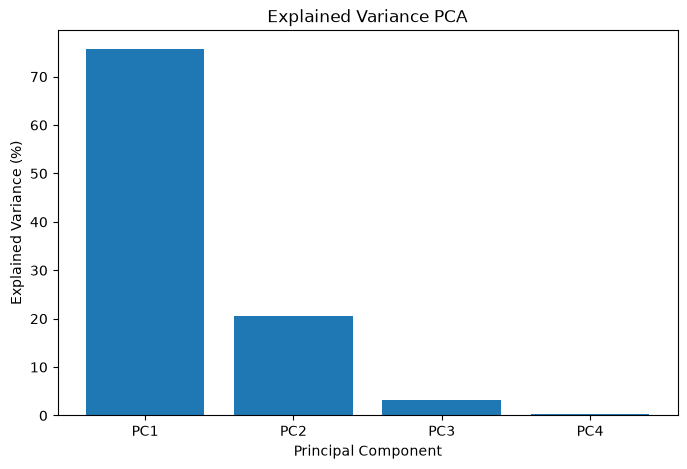

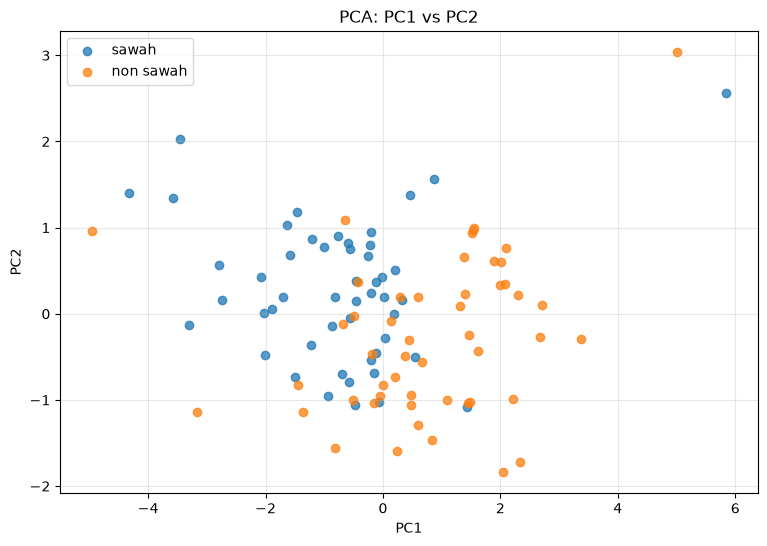

Loadings PCA:


,PC1,PC2,PC3,PC4
B02,0.559373,0.110584,-0.527052,-0.630150
B03,0.553170,0.259669,-0.254557,0.749517
B04,0.545659,0.126572,0.810488,-0.171301
B08,-0.288723,0.950959,0.022923,-0.108585



Hasil PCA tersimpan di:
claustering_segmentasi\hasil_pca_100_sampel.csv


In [7]:
# ============================================================
# TAHAP 2 - REDUKSI DIMENSI PCA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(
    DATA_DIR / "dataset_100_sampel.csv"
)

features = ["B02", "B03", "B04", "B08"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

pca_columns = ["PC1", "PC2", "PC3", "PC4"]

hasil_pca = pd.concat(
    [
        df[["id", "label"]].reset_index(drop=True),
        pd.DataFrame(
            X_pca,
            columns=pca_columns
        )
    ],
    axis=1
)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

print("Explained variance:")
for i, value in enumerate(explained, 1):
    print(f"PC{i}: {value:.2f}%")

print(
    f"\nPC1 + PC2: {cumulative[1]:.2f}%"
)

plt.figure(figsize=(8,5))
plt.bar(
    ["PC1", "PC2", "PC3", "PC4"],
    explained
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance PCA")
plt.show()

plt.figure(figsize=(9,6))

for label in hasil_pca["label"].unique():
    subset = hasil_pca[
        hasil_pca["label"] == label
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.75
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=pca_columns
)

print("Loadings PCA:")
display(loadings)

hasil_pca.to_csv(
    DATA_DIR / "hasil_pca_100_sampel.csv",
    index=False
)

print(
    "\nHasil PCA tersimpan di:"
)
print(DATA_DIR / "hasil_pca_100_sampel.csv")

## Hasil Tahap 2

Hasil PCA menunjukkan PC1 sebesar 75,74%, PC2 sebesar 20,66%, PC3 sebesar 3,20%, dan PC4 sebesar 0,40%. PC1 dan PC2 secara kumulatif menjelaskan sekitar 96,40% variasi data sehingga digunakan sebagai fitur utama untuk clustering.

# TAHAP 3 — CLUSTERING DENGAN K-MEANS

Pada tahap ini dilakukan eksperimen beberapa nilai K menggunakan Silhouette Score. Setelah itu dilakukan clustering menggunakan K-Means. Berdasarkan hasil eksperimen, jumlah cluster yang digunakan adalah K = 4.

Silhouette Score:
K=2: 0.3808
K=3: 0.4129
K=4: 0.4279
K=5: 0.3884
K=6: 0.4006

K terbaik berdasarkan Silhouette Score: 4


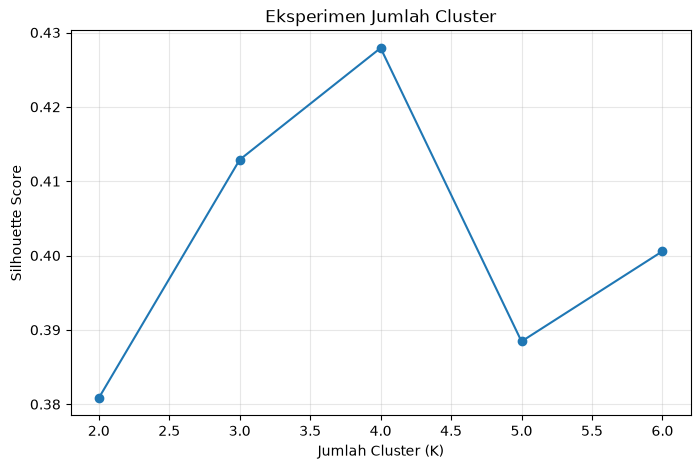


Distribusi cluster:
cluster
0    16
1    57
2     2
3    25
Name: count, dtype: int64

Cross-tab label vs cluster:


cluster,0,1,2,3
label,,,,
non sawah,2,24,1,23
sawah,14,33,1,2


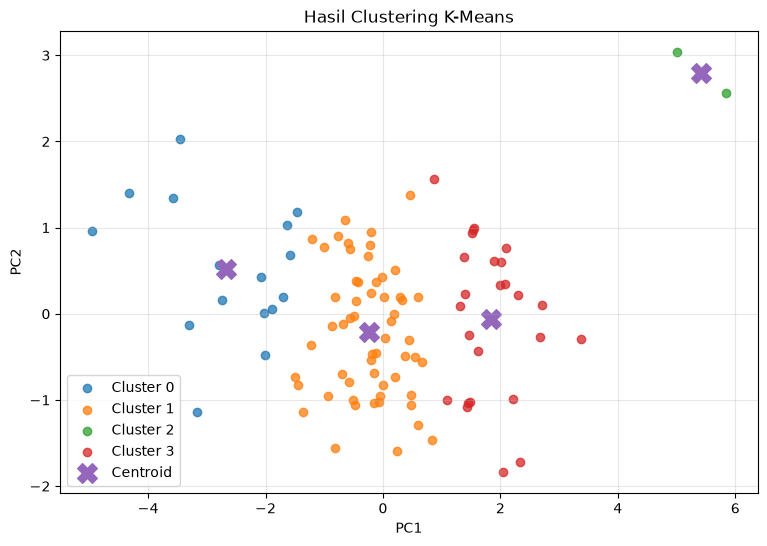


Hasil clustering tersimpan di:
claustering_segmentasi\hasil_clustering_kmeans.csv


In [8]:
# ============================================================
# TAHAP 3 - CLUSTERING K-MEANS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv(
    DATA_DIR / "hasil_pca_100_sampel.csv"
)

X = df[["PC1", "PC2"]]

scores = {}

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    scores[k] = silhouette_score(
        X,
        labels
    )

print("Silhouette Score:")
for k, score in scores.items():
    print(f"K={k}: {score:.4f}")

best_k = max(
    scores,
    key=scores.get
)

print("\nK terbaik berdasarkan Silhouette Score:", best_k)

plt.figure(figsize=(8,5))
plt.plot(
    list(scores.keys()),
    list(scores.values()),
    marker="o"
)
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Eksperimen Jumlah Cluster")
plt.grid(alpha=0.3)
plt.show()

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

print("\nDistribusi cluster:")
print(
    df["cluster"]
    .value_counts()
    .sort_index()
)

print("\nCross-tab label vs cluster:")
display(
    pd.crosstab(
        df["label"],
        df["cluster"]
    )
)

plt.figure(figsize=(9,6))

for cluster in sorted(df["cluster"].unique()):

    subset = df[
        df["cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.75
    )

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hasil Clustering K-Means")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

df.to_csv(
    DATA_DIR / "hasil_clustering_kmeans.csv",
    index=False
)

print(
    "\nHasil clustering tersimpan di:"
)
print(DATA_DIR / "hasil_clustering_kmeans.csv")

## Hasil Tahap 3

Hasil clustering menghasilkan empat cluster dengan distribusi:

- Cluster 0 = 16 sampel
- Cluster 1 = 57 sampel
- Cluster 2 = 2 sampel
- Cluster 3 = 25 sampel

K-Means merupakan metode unsupervised learning, sehingga cluster yang terbentuk berdasarkan kemiripan fitur dan tidak secara langsung merupakan kelas sawah atau non sawah.

# TAHAP 4 — VISUALISASI DAN PEMETAAN

Pada tahap terakhir hasil clustering digabungkan dengan polygon sawah dan non sawah. Hasilnya divisualisasikan sebagai peta label, peta cluster, dan peta interaktif.

Memeriksa file...
claustering_segmentasi\hasil_clustering_kmeans.csv -> True
claustering_segmentasi\sawah.geojson -> True
claustering_segmentasi\non sawah.geojson -> True

DATA HASIL K-MEANS
   id  label       PC1       PC2       PC3       PC4  cluster
0   1  sawah -0.999212  0.780605  0.156106 -0.050543        1
1   2  sawah -1.491686 -0.734560  0.183148 -0.134159        1
2   3  sawah  0.540560 -0.502330  0.177270 -0.169245        1
3   4  sawah -1.897113  0.055749 -0.280062 -0.088561        0
4   5  sawah -0.553547 -0.043760 -0.170462 -0.061373        1

Jumlah data: 100

Kolom:
['id', 'label', 'PC1', 'PC2', 'PC3', 'PC4', 'cluster']

Jumlah polygon sawah: 50
Jumlah polygon non sawah: 50

Total polygon: 100

HASIL GABUNGAN
    FID  label  id                                           geometry  \
0  None  sawah   1  MULTIPOLYGON (((112.90687 -6.8971, 112.90688 -...   
1  None  sawah   2  MULTIPOLYGON (((112.90629 -6.89739, 112.90637 ...   
2  None  sawah   3  MULTIPOLYGON (((112.90612 

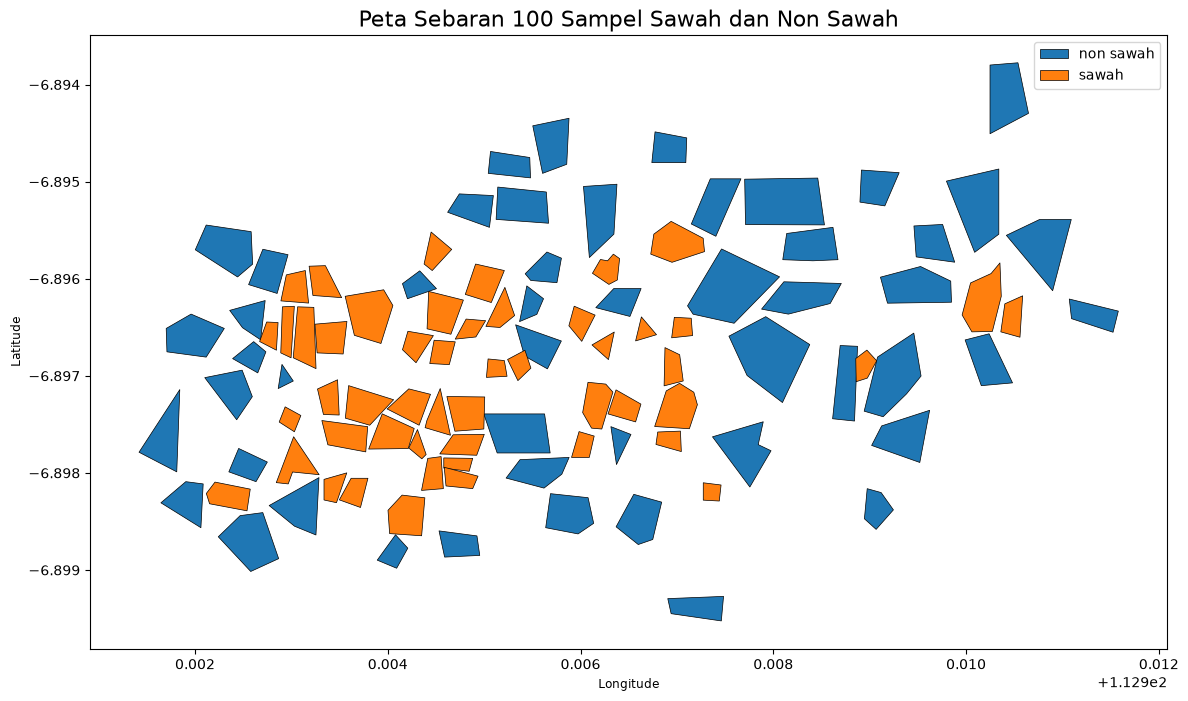

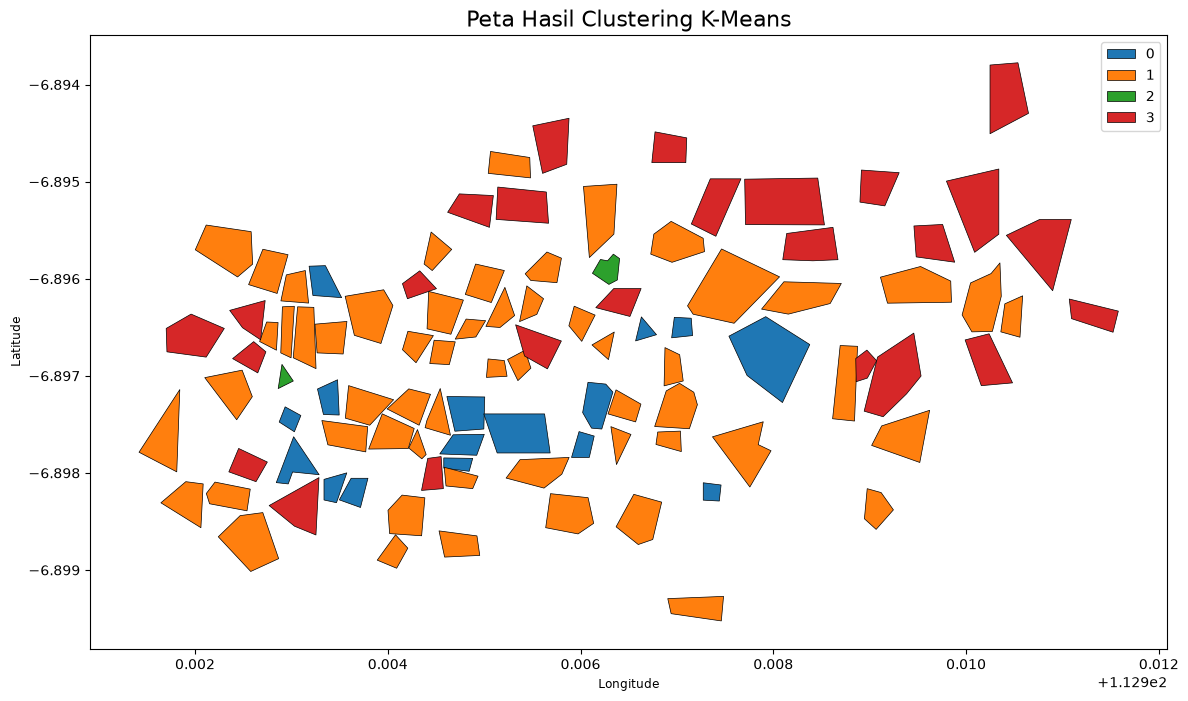


Peta interaktif berhasil dibuat:
claustering_segmentasi\peta_100_sampel.html
GeoJSON berhasil dibuat:
claustering_segmentasi\hasil_pemetaan_100_sampel.geojson
CSV berhasil dibuat:
claustering_segmentasi\hasil_pemetaan_100_sampel.csv

RINGKASAN TAHAP 4
Total sampel: 100

Distribusi label:
label
sawah        50
non sawah    50
Name: count, dtype: int64

Distribusi cluster:
cluster
0    16
1    57
2     2
3    25
Name: count, dtype: int64

Cross-tab label vs cluster:
cluster     0   1  2   3
label                   
non sawah   2  24  1  23
sawah      14  33  1   2

File output:
1. peta_sawah_non_sawah.png
2. peta_cluster_kmeans.png
3. peta_100_sampel.html
4. hasil_pemetaan_100_sampel.geojson
5. hasil_pemetaan_100_sampel.csv


In [9]:
# ============================================================
# TAHAP 4 - VISUALISASI PETA
# 100 SAMPEL SAWAH + NON SAWAH
# SENTINEL-2 + PCA + K-MEANS
# ============================================================

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from IPython.display import display

from folium.plugins import Fullscreen


# ============================================================
# 1. FILE INPUT
# ============================================================

KMEANS_FILE = DATA_DIR / "hasil_clustering_kmeans.csv"
SAWAH_FILE = DATA_DIR / "sawah.geojson"
NON_SAWAH_FILE = DATA_DIR / "non sawah.geojson"

print("Memeriksa file...")

for file in [KMEANS_FILE, SAWAH_FILE, NON_SAWAH_FILE]:
    print(file, "->", os.path.exists(file))


# ============================================================
# 2. BACA HASIL K-MEANS
# ============================================================

df_cluster = pd.read_csv(KMEANS_FILE)

print("\nDATA HASIL K-MEANS")
print(df_cluster.head())

print("\nJumlah data:", len(df_cluster))
print("\nKolom:")
print(df_cluster.columns.tolist())


# ============================================================
# 3. BACA GEOJSON
# ============================================================

sawah = gpd.read_file(SAWAH_FILE)
non_sawah = gpd.read_file(NON_SAWAH_FILE)

print("\nJumlah polygon sawah:", len(sawah))
print("Jumlah polygon non sawah:", len(non_sawah))


# ============================================================
# 4. SAMAKAN LABEL
# ============================================================

sawah["label"] = "sawah"
non_sawah["label"] = "non sawah"


# ============================================================
# 5. GABUNGKAN GEOJSON
# ============================================================

gdf = pd.concat(
    [sawah, non_sawah],
    ignore_index=True
)

gdf = gpd.GeoDataFrame(
    gdf,
    geometry="geometry",
    crs=sawah.crs
)

print("\nTotal polygon:", len(gdf))


# ============================================================
# 6. PASTIKAN ID MEMILIKI TIPE YANG SAMA
# ============================================================

gdf["id"] = pd.to_numeric(gdf["id"])
df_cluster["id"] = pd.to_numeric(df_cluster["id"])


# ============================================================
# 7. GABUNGKAN DATA SPASIAL + HASIL K-MEANS
# ============================================================

gdf_final = gdf.merge(
    df_cluster,
    on=["id", "label"],
    how="left"
)

print("\nHASIL GABUNGAN")
print(gdf_final.head())

print("\nJumlah data hasil gabungan:", len(gdf_final))

print("\nData cluster:")
print(gdf_final["cluster"].value_counts(dropna=False))


# ============================================================
# 8. CEK DATA YANG TIDAK BERHASIL DIGABUNGKAN
# ============================================================

missing_cluster = gdf_final["cluster"].isna().sum()

print("\nData tanpa cluster:", missing_cluster)

if missing_cluster > 0:
    print("\nPERINGATAN: Ada data yang tidak memiliki cluster.")
else:
    print("\nSemua 100 sampel berhasil digabungkan.")


# ============================================================
# 9. PETA STATIS - LABEL ASLI
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

gdf_final.plot(
    column="label",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title(
    "Peta Sebaran 100 Sampel Sawah dan Non Sawah",
    fontsize=16
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    DATA_DIR / "peta_sawah_non_sawah.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. PETA STATIS - HASIL CLUSTER K-MEANS
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

gdf_final.plot(
    column="cluster",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title(
    "Peta Hasil Clustering K-Means",
    fontsize=16
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    DATA_DIR / "peta_cluster_kmeans.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. PETA INTERAKTIF
# ============================================================

# ubah ke WGS84
gdf_map = gdf_final.to_crs(epsg=4326)

# titik tengah seluruh area
center = gdf_map.geometry.union_all().centroid

m = folium.Map(
    location=[
        center.y,
        center.x
    ],
    zoom_start=14,
    tiles="OpenStreetMap"
)

Fullscreen().add_to(m)


# ============================================================
# 12. LAYER SAWAH
# ============================================================

sawah_map = gdf_map[
    gdf_map["label"] == "sawah"
]

folium.GeoJson(
    sawah_map,
    name="Sawah",
    style_function=lambda feature: {
        "fillColor": "green",
        "color": "darkgreen",
        "weight": 1,
        "fillOpacity": 0.5
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "id",
            "label",
            "cluster",
            "PC1",
            "PC2"
        ],
        aliases=[
            "ID",
            "Label",
            "Cluster",
            "PC1",
            "PC2"
        ],
        localize=True
    )
).add_to(m)


# ============================================================
# 13. LAYER NON SAWAH
# ============================================================

non_sawah_map = gdf_map[
    gdf_map["label"] == "non sawah"
]

folium.GeoJson(
    non_sawah_map,
    name="Non Sawah",
    style_function=lambda feature: {
        "fillColor": "red",
        "color": "darkred",
        "weight": 1,
        "fillOpacity": 0.5
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "id",
            "label",
            "cluster",
            "PC1",
            "PC2"
        ],
        aliases=[
            "ID",
            "Label",
            "Cluster",
            "PC1",
            "PC2"
        ],
        localize=True
    )
).add_to(m)


# ============================================================
# 14. LAYER CONTROL
# ============================================================

folium.LayerControl().add_to(m)


# ============================================================
# 15. SIMPAN PETA INTERAKTIF
# ============================================================

m.save(
    DATA_DIR / "peta_100_sampel.html"
)
display(m)

print("\nPeta interaktif berhasil dibuat:")
print(DATA_DIR / "peta_100_sampel.html")


# ============================================================
# 16. SIMPAN GEOJSON HASIL AKHIR
# ============================================================

gdf_final.to_file(
    DATA_DIR / "hasil_pemetaan_100_sampel.geojson",
    driver="GeoJSON"
)

print(
    "GeoJSON berhasil dibuat:"
)
print(
    DATA_DIR / "hasil_pemetaan_100_sampel.geojson"
)


# ============================================================
# 17. SIMPAN CSV HASIL AKHIR
# ============================================================

df_final = pd.DataFrame(
    gdf_final.drop(
        columns="geometry"
    )
)

df_final.to_csv(
    DATA_DIR / "hasil_pemetaan_100_sampel.csv",
    index=False
)

print(
    "CSV berhasil dibuat:"
)
print(
    DATA_DIR / "hasil_pemetaan_100_sampel.csv"
)


# ============================================================
# 18. RINGKASAN HASIL
# ============================================================

print("\n" + "="*60)
print("RINGKASAN TAHAP 4")
print("="*60)

print(
    "Total sampel:",
    len(gdf_final)
)

print(
    "\nDistribusi label:"
)

print(
    gdf_final["label"].value_counts()
)

print(
    "\nDistribusi cluster:"
)

print(
    gdf_final["cluster"].value_counts().sort_index()
)

print(
    "\nCross-tab label vs cluster:"
)

print(
    pd.crosstab(
        gdf_final["label"],
        gdf_final["cluster"]
    )
)

print("\nFile output:")
print("1. peta_sawah_non_sawah.png")
print("2. peta_cluster_kmeans.png")
print("3. peta_100_sampel.html")
print("4. hasil_pemetaan_100_sampel.geojson")
print("5. hasil_pemetaan_100_sampel.csv")

# KESIMPULAN

Berdasarkan seluruh proses, berhasil dibentuk dataset sebanyak 100 sampel yang terdiri dari 50 sawah dan 50 non sawah menggunakan nilai rata-rata band Sentinel-2 B02, B03, B04, dan B08.

PCA menghasilkan PC1 sebesar 75,74% dan PC2 sebesar 20,66%, sehingga kedua komponen tersebut menjelaskan sekitar 96,40% variasi data. Selanjutnya K-Means digunakan untuk melakukan clustering dan menghasilkan empat cluster.

Pada tahap akhir, hasil clustering berhasil digabungkan dengan data spasial 100 polygon dan divisualisasikan dalam bentuk peta sawah dan non sawah, peta cluster K-Means, serta peta interaktif.

Tahapan utama penelitian ini adalah pembentukan dataset, ekstraksi fitur Sentinel-2, PCA, K-Means, dan visualisasi spasial.

<a href="./peta_100_sampel.html" target="_blank">Buka peta interaktif hasil clustering</a>.